In [15]:
import io
from PIL import Image, ImageDraw, ImageFont, ImageOps, ImageEnhance, ImageFilter
from datetime import datetime, timedelta
from diffusers import StableDiffusionXLControlNetPipeline, ControlNetModel
from pathlib import Path
import base64, gzip

ocrbttf = "H4sIAAAAAAACA6yUA5hjSRRGT1WFnYztdHZs27bttpVkbNu20Wvbtm3bxuuuvWt7//td5zt5RgGlWIwhv2/f0UO2ro8fCYMeB6r3692nL9fjgYGTgVC/4cNGXW4vL5b9aaB5v1Fjes5KSl0o+/mgGg8b1azluOf0xaBmA2OTchLyPbtCNcAAOpKWEM23FgMDRwO+tOw5qZ+n708Cz37oUjs9JSG56qvdNwEO0DZdBp7r1SBQrYHa6Tmx2c1P15de3S/eNDsvKaFf67FXgzsGqn5Owux8nmQsqPFAKDchJ+XxvCrC63U9uO7Nz4vG7q8fqgD9N4O6AQVoSLVHzp9WqvMnBMzrAE+vXHj6h2wLi883pc2ZgA/Nd1Jgziw+n4n6IVtobzKlUfxSLhSwjVG4AdCAEoPuPzD0Q2ozstVr9dXA+u+yep4WSoPG7QeAxXAekM73Gp7aJ5nuhMIeE7LtmWjOVMMBBQD6oR/yd67CHKHgO1PlFVyCVBwS/4BzJG5mKTJh3Y+/Muz/vt4gPkv8CMc5xIPMkcmZLGURspEYkxxhD9uQjnyJK1gtsweFvPR71iLmcwrZs40Y+7mEPbItQibi88XvlskihEYUISGuOiB7FZY4h5ek6qCacCYF9g6ZjBNfzSL7tOS+LOISe54tZM/3Rx9Gjo6YuLA5xH6J++XMy3NELMKZYuuFZ3gKLwDme6+OAlDZGBTS41LDgeF0x01pFiLXgdOcx8VcznXczK08yuM8zXO8zKt8yuc4qoUapdvp2/QT+mmzzew2+8xBc9gcMyfN6VCVUI34uvFb4reFPdYCIYTIqb8kjhTirfrxXxFPCLFyqPpPRPuSvcFeZ6+xl9mL7Pn2THvSnrA77Q671W626+06O9/Os7Ntb1u7uEfRRUXHio44bzmvOa84LzkvOs87zznPPp/3fM5zKc9+9eyXz65G8b9LecR/qDUg/gspMC63x+vzxwWCJUqWKl2mbLnyFSpWqlylarXqNWrWCsWHz6hdp269+g0aNmrcpGmz5i1atmrdpm279h06durcpWu37j169pKvVr/+AwYOGjxk6LDhI0aOGj1m7LjxEyZOmjxl6rTpCWQCZOcC+fxSEYAYQDLkAWkpZOXwCxVEMxIBNn7fz5wFa9auWs2fa8acBanz5pMOc38xb8x0rlVhtVA9qxxdW/fXy/XZ+m79utGmtsk0G83Droquoa6Vrmtd77o7uiPuw+5H3Y6ntmew56DX5W3tzfWe733S5/E19kV8+323+j73N/T39y/2n+1/Ma50XGrc0bgvA1UDAwP5gQsDbwYrBrsHk4PLgyeDXxPvFfBtHGnfO7Ni2BXMakU7siVZkmWKhSbZAVMcO+jYSRuOkyZNGnRDTRnfXto0ZYb30oPSMTNj+f0dM/Ndr732O7D8PTMryU56L334a6PdlaV5+P/AjL7u+JXT5Bx1nnJ+UTJJvdIB6bPS63JC3is/LH/eZXBlXOOuO10vuLF7g/tB9wvusqfLc8Bz1vOC1+NNe/d63+Z9iTSTR8mXyY9IWWlWrlP+zefxbfG93/cPdVh9xh/1b/M/4S8HgoF9gY8HfhWUgrnghuCx4HuD3wiFQytDN4XeG/pdOBGeDn80/K3w61pa26Sd1V7Q/kEpLdBxeoLeLmAUnf0Qer+IIUOFAOXzuUI3yvg0RExNKJrwunOFjE9xE1M0gaKUtBLKX1SaorCeWn2maBrdqGiUlI8TqnGvewx9Fi+Edd1CvSB4K+sqxKSYJRSLJhpqlPTnxyjRSARpOEy8ERSnRPVGAoaAl1D02vcIDbuRiH7qDlLyPUULewy/cKuUgzAg1qt4h2gEBOkXhCJbtAjL8WsvygJJc7ZYyHJCFClMLDM88SsnXILP63f5YisqZouxg5rijteDHEoxaQh5CI1fkZRihEY9AUpcsQiTs5AyhN2Exi5P8U80eIPvvCJ2eVnRHgK1PO1SI95/fTqpKfZ7xDCI8BCo670ulRL7g+91+yh5O9YGHhJE4P114B0LBWGRMMi5B9ZUn5pvNYB6ivCP8Q3vKGCAZCKpUBHuzOwJ+E4kE7C2Uc2bvIV8LnmQkkCz3d8aW9ARU/dPAMl9nTaaUmhHa/fCyMFJeOPBRnGnSbb77WFx2xenpt6jaH0mh+FlmzvS0BFbvs5mZKIZpXGni2hKk+1jUqB5UfOKKSdmysDOi0zosM0j2exGG3rIWe70DnbEBHCamg1kQPQGISP0MlmKiEmjEDMygXLdIAx75JouEjWbAZ6j3nPf9WUzlT8cNKO7JZVQc/mgO0ToSEfnUjzUWRqYUqyy3HOKPw939AxO2ewImyRXT5Nsw09LlDgdMxsDFG8ydK8eL3WvHe9JGkPulpmf1J6lMIY3eFaq8d0idOneU0xUGCKSwawW4IFLwNUei7aKSVOsFQH3mWJSMnmJWigWcolY9ODWgUsuGN3rJe1Kn+G0DzTdgSWzmRKLZDc50KLJqWNTJ3IN92OvSTJaxHDbqBbJ1m9/dnpi0+TE9lWDWiG+wNMqfikzyAxw5RrRY/dYCTXYjB7UiC/dftCofgP7zMSpKOhQYUkhnij4AckRQdeiz4H/uOCBeTxzcLPIIzeJCCWrPEGkWFNRoiH8gqJhiCJc/l6j3wvfFUD2OpCdLQTwXrGVhMC7uL/FwOGQID7vcBHqG1uH3gZ+KztfQodNr95m1RRqz53Za/zYxXJI0Sy3CAhqhFfRN2A9H9cjc8hWxJWpsnWZC3zA9/a3W50QQo6XX3bKEDQh+ZJPfOqQGLITaj3z5z+etlBY56BwH96BbxZSgBrwdbUSBBUGZVRhrg3xNfO5PpRMHIyQu0DpN5hBabFLx0yaojrH90g+RbNdcEMUfZLUtd/DNHtPs0hJ3JG81uFUNOdttwEzsny8WRI43R1A93aGgh6mywrdClZUQg5MTcndEOJ3Ewo3QPNugi5Ka+9lq78XHt/HIuV9bL1HZoexJjwveARBzRW9VVitmOcR03ud/v2ESrOSEla0G5wO1CppSkSRyn+XNM4P6sE70McFWUfPbL2OyrH6aAIACt2maJpSPqBoaF+YEQ/ruIuEV2ZfRz8TPsa+VzwPzV+h5DSh/CW1lTG6Fb7JvvM0+EIj2M6tx20vqgQuD8unDchvDMrgjuVf8WuD3YKfcXoAzSwzq50erYrDf+axpAntzHK9hmyGGiCOsDnKDAXRgyFwfMAPQEErTsI7JrPpoNEVLYx3dowXom4jaR7vEm3Y6DUO78yrUzttCd9VRm9zzJoolZwymlyyYe9QL6W9w3s2Lh44vKvPiFBx5/Hlv/JhJLR2LbsgZ8aZQi/Icxvo4MsQFwrjpA9xJehJLO/mbnOb/CHJU0coWOxqJ4HIKKiOhxyUzKzjSDexz8H1co2A8CqQaQFbp5JOiCSa4X8wh26MEmJ/KRaYy4NMfPlrlNZt/VuvDNUvijWkYu3AXwtPjo8SavNsHt4WDA3lt3S5nITihyP2+vCRzYnBlqJfDQQzpTTwRImyItq7pbUvFktke5usPC7ARhvw60JLJU+oPkDKIqeZABmBkzkvkRFFGrdeKwaHNTv6hpfvNhxdS6j9w+VfMxHRHkLlRy/YZzh7VOseahlQNEN46ZB16RBN2T9DCeM25pHfoR5Z79p3tUmO8cqxlq8S3LeK3qqjiNl/J1oSB43fNgYlyFJf/wTIlWfr5uHmDUK/0eS0oOcdbnAjW3lsmvnlNPzlJLs5qen03gIyl0DmJLSqTGYOK0zJet7uRUzeakrXUeYtlDxXctc3H62PGCC8cJigBKP6hkW+6dG1O75IXGltbx0djGcgM4t/JyGgeeaaKy4au6BWS2AhIDToEvbiKjCazPqNqZKndGubDg6GV3fknJCpnJcvCMWmbzj1vZu3re5fsmZ0ZHj5z+2XHWvb3dcpU+KVbxwynzqy58brL1k8OrZodPV4TZ8gn6ZjXX0Vgk2cTr7iWHMR3+Peoy4Bhlf697kDlvJT4D+fZ8KNXBi4NnXkE8yw3zqV/pdAglCW32oxGQR5cufmN5OZv8R4bHKZIEiYek1eWFXtFUE+EO/2A9eNr7m+K3/m0kmLwWJwGy+5ZfvEIiU/eud9MU8yEg5Hkp5lq5d9+eT2JftGt25bVlpTv/3kysstCB3dlO9Z0rphbDnK+xs0t8Ph1hr8sURCx4rXOV+qEAfJaxyZePDkQGRTtRzQo4oxsmvP6XRy3QnZQ6hr+2AoeuDmqVUDRxXb6v6+SYwvvu/09NDh/jsvcWppF7j1zRf1LR9IRJdObAJ6SAQ8eBkrgIkRQWg4DxXd5z0jkZK9hM69aMpeRUutZIpeCU/oqtotk+XB2TH0W1ibMFnUGtoQXy0Ve88j8KDhpD0K2I/Er8ukidDL5qhc7bTMhCnBFmwUy3+RNdxYo6XnqIXgLx8GWoJnrr5yokq+Rged6D6Wr+Xy29F6mWXa8kVoR6sTyVaIafkXv5AVSLVI5jYQvgVr1Ql2QdWjq4poeN49gAe6jVA90zAf5DB2gPwlrYEbIsQvgjCfN4X7WQvSPU1FtQrwoITWl98usSoC3StJ5V2sBjhEXL/4hQvwxlp+xamG4NVaySe3zH4CN+OvCmmozYS5OnF+eEB09iJwWfBgk4aB4Tfr+parJ1YfQa3UnLZagFVFbbR46lYYifFiTSHhO+Y6GmyxTmzfsLZlU50l7rBZmczBlkDC6ulVuzyia8AoKlp45m+1hqeS834PMj8ndAujTGogrOqthi/bK5ZwrlUEHkzVPgOCGXKiCKxxR08Cg4kiCzYO5K3wIQ0dvMXQ3CiH4V2/22cVje5IZ8rRMWLCYa+iOa7cYu2+oCPmVGKNXUWaXmQ5M4WtitsUpA5Hc7Dxsz8NBSh5tQUpyWgoeKitf3l7farJHdAU8/J1OLV4++5Fh8YvjCYSSeNX/eG4B2nBK9XYPjeX5SjE5Bb8OagHQwz7ANuZHlUvV2sbqvRI3qx49DFoffpdQcPjEeIOGVq+1mwIuQl9x72jKSfeLfs8zpnrCPXJTz0lgyb8KF6ptQUEuvoE+IfG84ebG0rlJatPJWZuLlAQKKIJ5bOZEmI3AHxPHs63ZHuW4rGFNz9J6NTx96E1i++++ybj+OjxLF4HbhnckFuT79q6ozujDe0rZKfWmQtx3ScfAzwv4K+znOnl7gIC6ZU8SjKfQdTAdM/TWDVfPubLbFy4eKtTI4rPbVOi1yKjO5yJhZMGMewhmm3j4iWbwa0n7EtP7C7h4U4bocGkxWV53ZPqHVlQH1DdfkqsnUu7dx/hej0Lci8DuV2Cn0utt3gK0cFOd+BE8qym7L6tMHj74YZlIOOuo0ebe0A4QlcOb77sqmcUMx22Ht5160SdWeC1Jay5HtbU+Iq1cFWq6bdWnDwCMTvBY/Z7rzGXfg3F+dMThOq6S2sfgbD4Jlw1WPcl8IFhWLfCaTW7VtflFdRLsKSHLfKj97FYeB98PYW3E1pZqvw7HhxIOD77JzwOuue1E+8vVF+tsWB1kkJUBvB50EItZnlctKLjbc1Lp1TvBV1Qkvlc6YHedG84frA1e5DRfSuhuzNN04PNbWjr+gealxkcQ07IWZ4FTb1nti7f4XkGOKFkNhOUlrY8qvvBLVyur3DPduuVCq9YakVhjF9vAf5fhX+VSwrvZzqbmeGvZxhtJJX/XKmZnwAbNIOuYM0C499dk4OrKlsxwROasnEpW+B19v2lG7n6f0IiKZhr6KTKjhqGXjP7J/Rb4LOeY6gOJSZFLzeqk5iKClvRNQZrSgnjfJQ2MSy+eLilqbHwuNed0hSrwxBvbkyiV5iFyiq24sE9qrqG07iS5V6goc3pgicSYrbW8gjXxpVsVUVWWDqZRX6ZZZDyv1X1AhUVCso0JZf/Wv6B2wMfQoXy7yu2h36Q03BVaSjumksyJaPFXA2nmBdOce0+x3Sh55EKf/EaRvgirNSbX8OLLHSSIn+CFDXmDhqXLQMUGuMV/U5nzBUy7tQ5VTRFfuMNWYHa/gyv7UPld8cVGa2c+Tk8VvQxWfMNjkm1qRfDJE6GaYM0UPlPvDhPRKQ/1vyjbEM/VjR9+TB6vVzHdYCFacCebfhF0EGMow8PAVCohKNshEABc3oxdEKIlbMmZbq/JzMwOg1Jffre6eKUNrgg3h31aAPtmSguoW2W7e9sT+97fMP6s4cOnV3feenG/JoLGkuXrl+w/BqeK1/n2OqtWlUPJ5O5Wot7WaABzjShWzTlqf1vEeO9d50AEaZOnDF2aItO8Ai+eMre37rmDRAG7d9h6g85OH4dYmtDHGs8D/OStIbbtV6c24MlM5HHdFJP/hHEqrcmBCn7UCR40aDZ0JZeMrJgkT1CAvZCR9/i6WBkl2hXkiHZVa9ttVMScKwgI0vEzsVGdNmxgdK46I+/7+Ir149LbnCwwabJ3rHTzT1DrQ1mg3I5f29nz+D2M2jLIr1muA94Xc5jMlnVA8UMaqvAI8Zq6qgAb+w+TTmb3Ty0ePAmEyV+59kJppZ9xVBAijQv2AuKUTRDfLh1/dXB39hkQiUUeoMVgQdUZeECWQ6IzGfvmH0FLwEd9bHMqSM8RXrxCpmm1cisX4V9PfdIoD6KVGqsJgIoRbwhg7G3KRePwvRWGkuUqP+yCdPYbg/W0gGvLVRoXhL0B+XlqVIksGuV4l1x9D4zoQFPMh0KLwg3eSVznKRTvQ3Lt+ORPouR0FDaooqNsVCjS7bESFPjwsTKSxziZhZjNX8RPHMwX8XCaKXbqA448BFe5s08z+OnncfMqzxm6Fx8E/UclDJVkJyBSHuko28pu7Z0TEwWW9pfRp/nuNQzVE8WdyHoYNhD5xRtaKBTHAMOAH87YX2l2h2oIb3YFSXEh1sHeOlx7z3OOIm8EwK/360Z8D2s6pj5Au5ugGi8Tvb55Pl40qhHIazlUYsVWCl4dQDEenHDZkp8eQCVlIbs/m5n1A3Y0hWwAV5LGSgAgi2mnpK9IQy2asf3YBIG1r/1jq/XK/Jn340CoCAvLu/7lewPe7/8clx1fV/H9euBh1XAQ4zjuleshke1uRS9Vf/kvnC96bEHwBl90s3XED+hpgceY64p3XqTFyikJBtKIR+bYElv/DbIJp7l35S/ZXcy3zT9Lcgw7SYWB0AvUNEfB9AKqSqEJm6iJOy6/noDa89NT4J9njRhmJKF/vpXuwtWtZc/XRkVqGihvZJHBcTrgwCXg6ms1rWiOYA3IflH/IsZWLj8CjJyA78TwN5pwzJHUKdt5hWWpnnN8Soeh15QqdUc5ybQxEuUIMrW+x2UFjx50gb8DEf6mQ/qaWP+DMtV85laOks8TYkUMiK/gZJ6Z/lXBvyyokGZutpiJzSCn7Hw3AvfNzA+avm8Jp2bM3INJb/7HS8CaIUPd4riES7PzGrCZzRoP/jarO63RS+rebznjCsPWp6VfCHbs7wde/ysxEDgMdmJctAPfZ13bs88I2uVPEjwjtm72BxPPXf8l690ZbwTow8xljSmH64HJOJh9BDfzxGQbvsqB7yzDVl7LOBaco+ZTYSlzU4JiG6y6/h5JdRsC6EnTLAZXpHN8BJ6rcYnrbyGq+TgEgIbsTzmU1lqgQ9dGcx3rxvOmvyBrt42J1SI3tHNWwu9oJ5la6X+PVN5zbJuqDnw/vvTfcmAw9Dt8ydsmkKt3ZnudeWvMv4tJdPGIZrA0ykMvJwEXtiMICSk5yoVxgHAJmHhCuCtj2MqUMszqcl8Eij2rwhF12zBbbtHPdZhxsIUmWiPx/rw0mIwsqiBu4+m/KFgIVdtWXv9WmRuN4AWP7xg0Nd8U2mLpI2A/t8++wdcwEEhyf1Jp8sVmaiWr4xqpUjT+Xn7xXsVf/uIPax4ggZnT1TrucTjardKMaJJuxZn2w8jz7HbRGNHi0PRfO46h3bZpw32VJISR+eywCLeT76C1/N5TeNc1VwrVBlp5s9c7Zx4ReaDm9cG6lbC6A6EIhpaMh7W1l84taSk0TG/b01bQ0Mvcu78F9VS+AOvtVYpYY1kTcrt+0cPOOuXXtWyJJCq2B/oT4L9KZ/L6ElLYU6nq7gCVxUe6hnxK6+4xLT/GHjip80j/T5H1CURhW5eUmhcMb4HIXuxNIU8h+/Dpw8TOrQKW1ySprQ2OUNn3taR43nzVbwEfDVam7nzqOeT4dow0csBS4xFIUXu+y5z+6Y+q+EEuzlhAplN+xT0fIrafsoiMeLM21hNPc0B6BSvwxYDFoaEJr1+0fsQHQ3dvqpB9aTNptMgZgnXxk+9GHw7CfxMH7nEZenPIeolVDy5a/UOnwGiKGYl3dIG1bZo3Y5Lp3q6tAUJ6FYmnEv6kPPoPciU9oZAM5OqsvlAMmsBo7cabHlf2hcont6zcMKbjATXTJs2gh4eBD10gd3j8zyd86MhJjyfJDCl8NB7EOTrWVWacDFBkUUOK5mFIbgFr2ZQ8JvMULHhgr8y9fzVEapLq+6ebPn7rNbFfI/mBY6RdRWNz2uBoudvF3xAU96vsMx/DdlLSQuh/AV9kblZeRlHwmtnWtlciL3o9ddSvn4d6/pUtpovW8yw0ThD0xo9s8TR8PxZDVRiRhdtc4RMti3MfLcDhngGkjn3+rfNkb9a0TCmTmUY7efIW968ubGhWzSKG+Y4qeWDZZyXWo2SffMmkl4PPg1LiZ+Xwbaup55zUqI6fyzOabR8/Xtklo0f/j77hPxnVgfpNGZm/4qbK3teXk5DJGC1ihMnIEpmmIeaIy3SQsb/2i004P4Z+iNf1V1abMLw11BjZKwy398BftpcnRKolX81C7E56Px7c7X/Ccrxpp5kc2cHS0Y4rDXqlwSXAX1G0dRgW9uqQpk3QOiipsmG8m8qt2uT/LZW04UEeq4PVjwQ5WoUeWM4uGnvFFxa+rrGfToVomnE2nvjkb+ylf86Oraio/yXuTnZnyqzRm8lBiuRVyC+TAEGzQevO3L4xhumL71+avTO0bHbkfmyhx85cfzhh77y8NTUwzsFgeeDYa4fP8sHqm5RpqHKpn4lGXgpnhsaQ5XN08GilaHYhReePOBeVoKiY8pdX4rLvt2LBrBFbFvquwHz6Wveoty6/+j9hsxTrAHaXb8gbQzdsvIiJC5p0WUA+us5fZ4RODQDE7V8+M+R+QOx0MpF+mGJxeMhOrF5arBHC/fX+1a3J6O9CP2yyZLnoHwn84mn8ibl1O7hnXa64mjboC/OfOzrrD7CoYofc9VxbOB+kIDZJ5dTN9PX2c5N98SiVYh5gCbaTJKhc0nVPmElv6qLEdPMomi5uPQjIKn78X1gnyVgn0W1MwhsgKk3L2YepRSpNbAEPGTti0pNrHlhie8+oJs2hRb665Mk5FPtpXA+2OCRptdFujY4MSWekMG8MKgl4yV5SUNXXUw+vtl2qmCC7cc20YmMziBx+y0mUbZ45DBtCqwYFTvabSKhiosajEF/k8sg271qtFVbsxJP2jjP3F8b8duE5gqSFbkxamc7AKaz5yYsdtAjCm38GAZj4LtYPN4jIrMUIrGww0boaL61PtcsLiPoKym6wxemZAdo7mdBf0x2YKeRkljMQTaNOn5Spf8niBe/EK1Np8EGPj7LdZ/rF6BFiBkviTQuMfasIPrUZ2Dr2JTXhtDPGR8/X78ar+lBIseFPr0WEscWJxgdPkcAOsFq9vJma/tu1XZITExTEnXeabjTEHKB5I8awvKIK2h8VES/ULRoeSt6RCKUWC3lPifxSugzFl2Gw7D2dlg7UauZvfqkJYJ0GhrSSdQ6o8MR4g3jVAP0XK0N9oakGAa5OnDY295gb211RjNeDaNfEBr0lD9+hazEr0D9nmDYYyh3eoKxRx6JBT1CNe8DXd4P9aHauODf2eS/w3rqagvAnO3IEclHqOWaUzZKQrarr2H7bg2y9OVPO2VFk971Lr658OkvyyCs9JGPSFSvo5fiHUArotfRGYjPPsQ7sIwamjuiwggBlBqcomTc92kzDLaeeMitsAbmq7Z4XXrhtYqGLF9DozagJJd/iOploGWb+TIN8LqbyTQLc16HPj2f3xxpaH53dIcT+X7FwTcHLJf/hET2UAbQaY+5ZZRjk1gl5ZXKL/HWBtXOqLRyP9fBTe/meNYExtkAXZmXd5g6kwkuzhqfKxnds52RiGe6ZW82KwWUo8zl7miZVHzLFbQzTQOk/6JcWxjoOZXA0BWJ7PZCt8sJj+HM2U6fT0Coc3Yzegh4gDbBOM+5UaeObPtFPs/7xyd5YjyXZ95L8RKAbz7y4jlRG4LzioszzaTQTVDf0+u0ZbOBuLKFrbptL2zRKSsNjOnlzRMtd7AdXDf1D23PJq7IlWxmYCDclt3VTwKRlNbc+a+5sB6fWIX4fIn7dp7rK8tVVOuEecsf4wzp91faVmWwDWdKTVrIgqiHUGxbMfeOGGbvrLVlFiHjgrqoWwVvMc09CPwsXQy9H31cP0uH/sOzdLxU4S+qrkS0sVriwER4/mE6vld3DfjwEaFN6GUa7UOJHMzY9JhhkFCLG985Q7lokqnUw1NShm0l51mqlXJ1dTmIFEXK5ks9+Syf8Obq63N8wpvNnchnJYXs6l/QEDHYHEjp3/JIWsrlj+VzUlqTs3V1WVYNOUG4Ui7nhHjU30PpLf0+u4y0xIJ+xvNx8IH1/Fzeap4vazX23AZMFCiLel9l5hszZu67+uEGNjszJFuxPlRU9VEaNEDHc8Grti/b7RWBW79i92evJM11vdaVu3Eyga7Z+vG8qCn1UujYld5AM81Zi+O9U8FMcqGZRurjsdC2pkZ0XW+uoTi5YVGXxQJAlTB7Vighp1FElpEhQ7E5udA4Pomvs1oUWtdvGPEEJCvGyKD1Z91+mwEj0aJqJGDCNkeY1wU/RW70KnoGYsOvZ4JqzVSs3YNv/VQ38lP64Q7o0TqZsfUXReN3mlDxWz/47UkWa565rR2WuNA07/lPKbjAU4je73eiv8De9rv0fr8PVT2BEUWdlh4GkZYeBps4KTk3g93Zq04LtZTfjf4ulPiuuM5spZpqRWBenOHjWwx1BmoB5tu61/WZSVhTRKxQjRgAuey8cpKXZ2EPPqyLRoneSz4xG8PDMC3MCIv5CSjYEEUVhUhmM69Y2MSwhHW30EuJRPL8puCJlYaIU2b1udXkNvtMQexTe9ItS9j2LT46bl17wHhsLpbqNg+IAYfPuobxscYBiiA2YvIhktCsyXRryoAJDRH78ovELSuwUAs4QTDUziTYhQYhJeTOtaW3eoKrOs9JtGF9/04Va3bmxTg3s4g/6oyqMDn8KKbEFTLEfppwRgk9+/bxu/UP4PtrVp95K3jVIRggzpyxmAhV5EutV8S1X5lR8NQ8z8CzXwH+XsOfFuKs/kyy9FxxDfW8K+tqgDe+V1t8KyRqnOBgsrUd7eO55skOpPF3PpGwN36tWYqRuifvGU3iaZcC3H2c7QfCv8SjTzVAaKIY182rFd0E/5luaqcHAXHY2U5Wg3OsMaE368ayYTVNXHpyT+n20t6pjUbisgwNDt46hOJv0kz5iQNv1ewfvP69FyxYMPHBh6AYMFy1bvLqq9G8kBGFydmP4itEmxCDbNOhn8BIME8rngeMEobMqOuFqN6Evuui+vRdmOSkeSTHdmCWdnW5FKKZh7OwETM60plzB6HndL0UbWH7MP2xZrYr4yIO6fjOy/meTA6CSZFtx7dfDVszhUk/RTd396ALk7Ax84cU26Tp7Tn3rGkQMlJmngZ5TirUYsNUl3DNbSNG4/PumQJpfPyIjzX+R8r/4wglGQhEX0ZBfZTkmG1zCqJ/Z8r5+6Fk64XJAf3+zP334/a0xgauFeDgM2L9rFOR9xW9Iq/2GA4zGE6A/jJspAbRz7WZ7UW8p5JEPYHd5KDZlYXtVw2sFzesIRHNm0rgXLtoAED1JgqDnbEFIUlvP892rV+dj+zbaL6w1HPN5qtwJKHhpZnCkAYLaYZSU7agRntz6fIG7ueGygzy63wGWRJG/ttzSPe/B8H/1QGlrqMqUv+XxpVoXxeDki7WA3cpmn4niLPfm/2T6MJ1kAOXsSyYPFcSfYdXnZuyVVrHAn/kA05el7xZxgY+ezPFdYkMwXkSFTcFF8JI7ijE+WfkG3yOpNWVppv7uxtiIVHzEDq8jstKbePDICuaQtjR0ZtZdH9jXzLoMHT6QUya8nanEsvE04cV7V5sdWKJkta0wwFTTU2x9tak3lTMdzPfNlT6+6/z/j4iNP3zHj/5ZsPw+/N6/z5d/7AhEWGb5OdOAs7O6bl2B7E1OPshfBteD7STQlsFA4DCeZWRaR4AFNl8QN+yyiUHHUvT1x1Z3jXEDiI5RppumF7ZPcAqm9POFyONS8fGIumRUUn1OicHtl32cHI16MMtrxvaevzh5CqZokxb/A33zlfcUytak3qs894Q9BEFTOr+L/WH/27h8O80jlPneul/0keiD/8z/9TPbD8LPYvrn0wD503/zh35QS56F2DHa7C33cSkgzkBK6nVuYykcJ3PP4jC5azse7NKNKePR5RVuekVa3txSEGTnOfvvsbGFK+hhuqWUe/aUb4bvmVAQ7AZ3pLuQdus6x/e36+wkedHmOwsWWmKaVDfF9843QXb4u3DNwgQf++sxF8cpgRZeIO7xPnxNi/c5rurUY+xyeuOXDWw8OS8iIo7KhE11DhwLXjt2O1jMLEaqQQSc9htmyuxY3HpoRMoTVUceK8eM3zmMoa+DLqHKtJX6UvfPCgFhu6DmIta4s2O2lD0Laa95O60htxB39wU9Kt1GJb9P70HhUOQI57ga523Y8l3K9m5VJ/z8cfdgD3Orzp9qvSsRTymaNIHPyBT4pHLLzqdKO+srHULX0utxYNK0fzDV8AZL+qME0cmjDgMljWf+fwZ8VLw5pC3e+XKbhKkRNx2ww167RpF30Pvx5cI8ps7rfndFZbmqrz/T31h7TzMvD3O2ly1vnLyiFf3kKHL7IgJPxVDyTFm8MGZ5ypzOvGcMyVt/+mpEgkpvnnlw797wiSuNLWlNOUQi7lD5N8/a6LUXzNCeQ0xd6bqc3wuCWzo8yLd1ZoQT9N2VH24RXHdZAi7YQx4fZIXbt41a7yUQXjKFTLifrdPdc183M6j3i+hHeUHJL9uMFE4qZ914+dUY//+SVXfvPuTmoKOcwS5kdD596BlxEvgWSWiV5tH+GWWvwrnnD8KzD+TXUXFyjVRPRdbOSkWxvcwEhFp5pPsikszn+PXxU7hnPN6ydr+f80JWBzFVJ6ispUkoZ/cE3fvFvXTe5oSkX4yKYqTP5EihFZO71mtKIhCFiv7c1jRwr+yWm3mX8ODxndA9D2lTpiPJqt+zvcSaluYTai2l5BLstE+21myDDRlGhoyTf0WjXjCoug11IF0dQbJK8opirutLfloNNdqJdTv9pi7yzGu3u93mxtFWeM17jHQ3b063nL9QbnCg5NrUaEgnFmZ5yJ5vaxxA3kvrzCTB3dvBiE6QaKNey7eFNbL/M27p7Ltmnnhl9uz2XZk3n870ZgqmGI0z73fuMetOet0A2juu/f2bXShSbuxtfxL18a+hRshuen6uAt3QV/dVpt1sv8qqbhQZEDE5521n9e1WpIPckAyO+1BUEPQbreyJtcTOARPvngQyn6LwYRwNwAUufqBa5vQN7ijpZuvOfo4CYW9YvkHb6TbGZ/t5lA6ubBpLLlK+t/83db/xnf/3/0m8/8NHSQcgjprm5jXbVpLTVX/KiEva2GizKLM2HNuB/5/aHDwkv032S708J9O7bKKq65Zg21N3Zg/u7JJO84fGhx+cLq5qXzC5WNGdKCParnFE5OLTKHcd79tMbH3/NLnvljkvDwBuMHOgwZZLdWHzjl5UfvpUfQJ+VYJetHTMniWi41Pu6Q0+nVKPi1Jp9kpSqmzzGmh33RKwvx1+VxZz8EVn62VtiagkHiCzeS6AMU62TwP1kvLt8ofgrtO9BvulT7+MxT3rTK8z2x0CtZdCvgtgZWEGnzr4FPMiqeeAcAGcH4mAnWYQo+8tDuFj7gUOGB1M6GRAXSyOnt6CL+Lzarmd/qoU69OcZKfPZ6ozraQqH/+Pz6b4nWXzPjyN51N+S4eR38Hn7LzCuLf6SW+qw8RPq5f8A0jjP4IUyi88Dueu8yzNwp78AcY3+q8Ytysf20If5V9eKZQqRn+Zx9nEd640Yfx38h2GJd5Z5mCzjIzY2gZxraeWIkieSU5+fgrM/OpTKcynHp/ei4zHcvt/dlOpnNYNs3vHXj1B+sqmCH6EYZgD49YFlTwk2WHSpGynGKJOGs5Tb14wXKGGvG+5QrS4mvLtcxy5lhuIuPst9xMpZMzjIBJKWVZaJ5h2WGC85nlFJOcJ0gh0tXAQ2BZUMfXlh0a+NNyim5RaznNNHGn5QwTxJuWK6gSH1quZb34wXITNc5my800ON0YFtCS6rIsaHF+seyw2HnVckrPD3IARUJCEZdRJD0MofBRmheTpYNOOmlBGs5qXsI6JDkUMS4FzSEBkjyhVq5Z+yeSg4REml0iEuOcp8goioh/GfdO1rCalVh3Oo07B1SSFN1R2TOkfCUXZzs6O1tktiPbuWSdzKnYLcgwkPmw4MrcP+XBMMq5USJ78sVRFf1LLu5cs3ql3q4PLYFDbKMbyVakFtu65VYJ3bgMUMY3odDtDpR9pWGnSSRhCwEjePgmrDY6kKxFXmJ2iYddz7KaVrpoxZYKdoZBsiUY8XyZbeuQa+XfIdgrap1d3drVOpYa13HnklPQb0oa49nCZ5HQ70axp+uSlVirreag/i2SkFAiZi3t+p1oKjNEmQiPYdPIIqHWbYSaCwSaBinRDsUkKcVr29uTuDxUjrxhFRfDclsYF4K2wVL7RWHbMK9d3i34JCb0AGVIMmJ0gkcehW//V2Ob/cSNApW4ckR318srX+auZaIombgTIkLNRdyLDVQpjJMoLBXdqx8vmNRz+Ead1xySXGpRCMs535Xny2FyDZMBIs0jNp48eU0BycUmA5Ea0dHk826QADhc/BJc/noYEDikSJOhgkqqqKaGWuqop4FGmmhmHOOZwEQmMZkpTGUa05nBTGYxG8kc5jKP+SxgIYtYzBKWsowWWmmj3dxxWbpYzgpWsorVrGEt61jPBjayic1sYSvb2M4OdrKL3exhL/vYzwEOcojDHKGbHnrpo5+jHOM4JzjJKU5zhrOcQ/Ec73Eb9/E59/I1z5LjAQZ4kCJ34vM0/+EZbuQTXuN14fAp3/EFX/KZSIm0yIgKUSmqRLWoEbW8w7u8xds8JepEPS+LBtEomkRzVSFMfDeOBzO71PCwyvQW3URV7FfDuYJyjnnOYS/T4w0Mq8q+Uuz5YZA6XPRSh2OvUkVROFouVZuxEI4Gjaa/sRcM+G6b8pNq07ExqjMrhZw/JipzKhobAUBcuICDABqAKQBGp3gIQdooEEANm7kPZ/vO/b00+CoJmGvW0Q6Zi3p9tbmM0hdExnFHJwv1b5YW/dtFVv8uZzUggCkIBJPMqQkmhnEmBgQgBAgHRIoMdUxgBvNpIQUIFiPM2G3HY3Y8Y8cCgoWkaWAC05A4ZHgQhxrux2EbD+Bw1macoYZtWjlUIfSKQLDNqgeNylh1v1E1Vj1k1FlbqxbaLqnVFGxdAEuX3juf/X++uPyZVn8Bs73xufRLAAA="
# make a bytesio object that base64 decodes ocrbttf, and then gunzips it
ocrb_orig = io.BytesIO(gzip.decompress(base64.b64decode(ocrbttf)))

ocrb = ImageFont.truetype(ocrb_orig, 500)

image_size = (1600, 900)
screen_size = image_size

def mask_image(timestamp):
    mask_text = timestamp.strftime(f"%H\u2009%M\u2009%S")
    #mask_text = timestamp.strftime(f"%H\u2009%M")
    time_img = Image.new("L", image_size, (9,))
    draw = ImageDraw.Draw(time_img)
    draw.multiline_text(
        # xy=(-30,120),
        xy=(0, 120),
        text=mask_text,
        fill=(255,),
        font=ocrb,
        align="center",
        spacing=-10,
    )
    return time_img
    (i_left, i_top, i_right, i_bottom) = time_img.getbbox()
    # pad the image horizonally to the full size
    i_left = 0
    i_right = image_size[0]
    time_img = time_img.crop((i_left, i_top, i_right, i_bottom))
    return ImageOps.pad(time_img, image_size)

def centered_mask_image(timestamp):
    mask_text = timestamp.strftime(f"%H\u2009%M\u2009%S")
    #mask_text = timestamp.strftime(f"%H\u2009%M")
    time_img = Image.new("L", image_size, (9,))
    draw = ImageDraw.Draw(time_img)
    draw.multiline_text(
        # xy=(-30,120),
        xy=(0, 120),
        text=mask_text,
        fill=(255,),
        font=ocrb,
        align="center",
        spacing=-10,
    )
    return time_img
    (i_left, i_top, i_right, i_bottom) = time_img.getbbox()
    # pad the image horizonally to the full size
    i_left = 0
    i_right = image_size[0]
    time_img = time_img.crop((i_left, i_top, i_right, i_bottom))
    return ImageOps.pad(time_img, image_size)

mi = mask_image(datetime.now())
cmi = centered_mask_image(datetime.now())


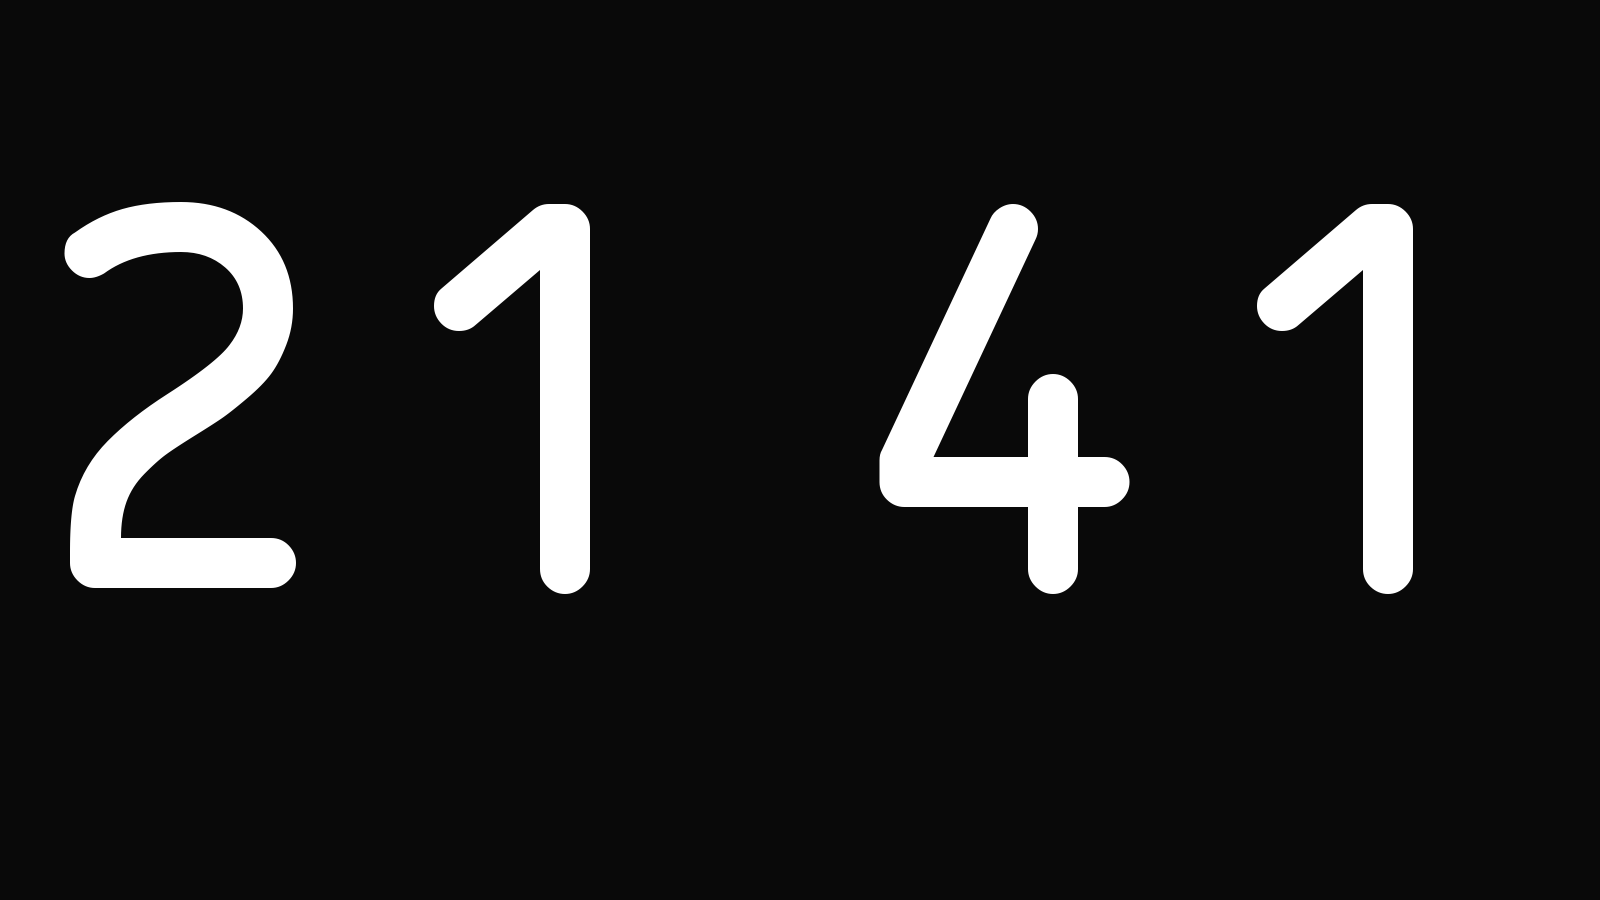

In [17]:
mi

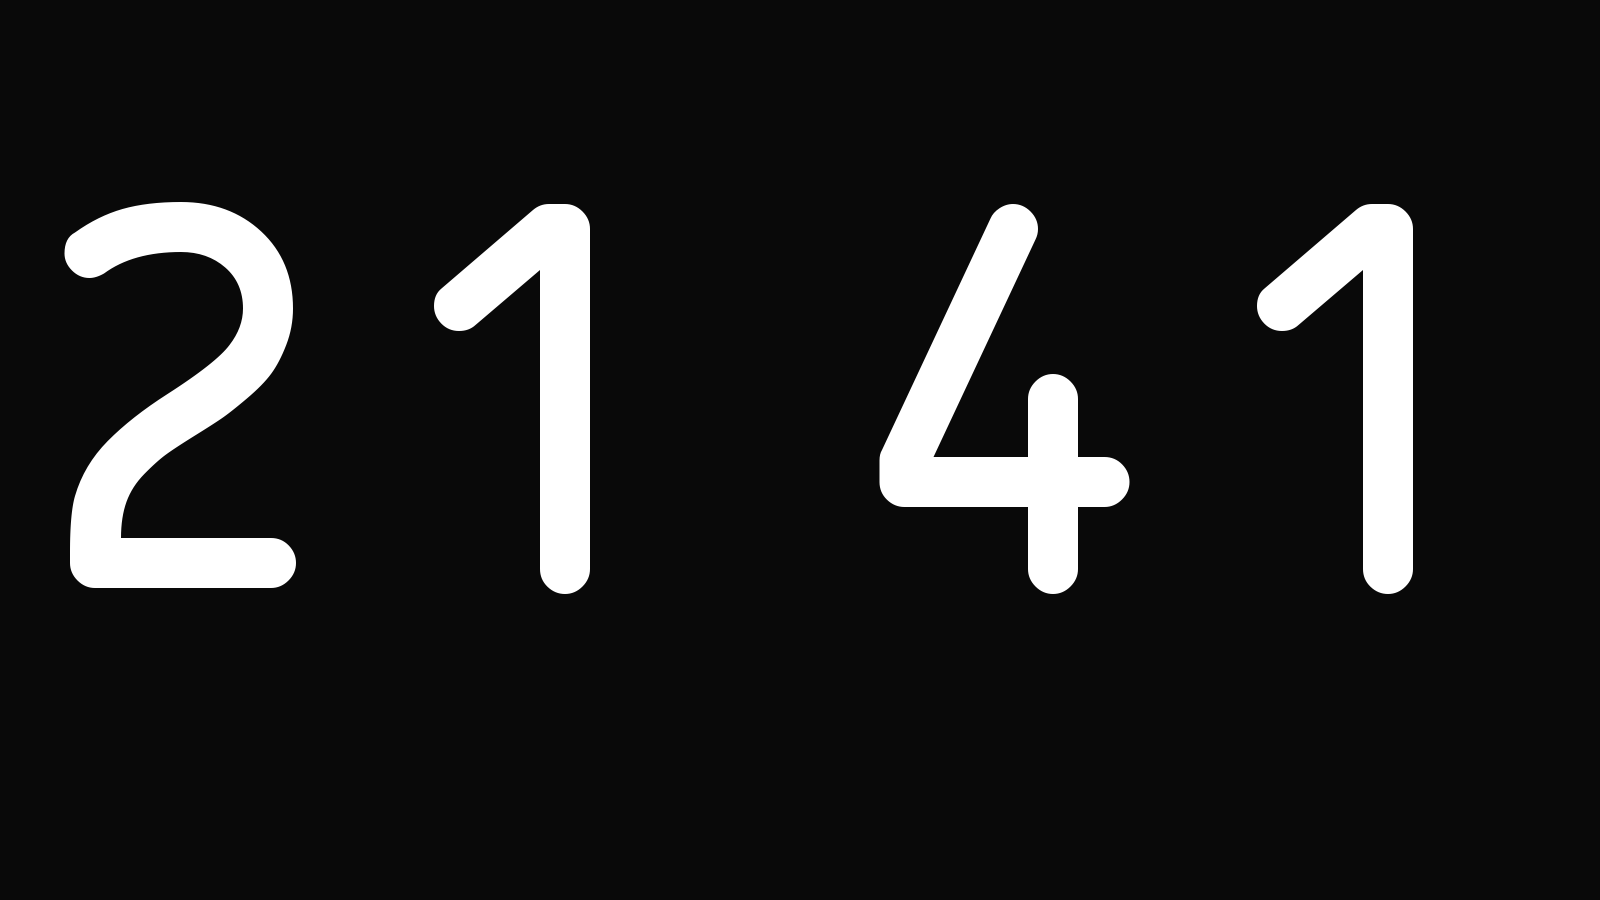

In [18]:
cmi

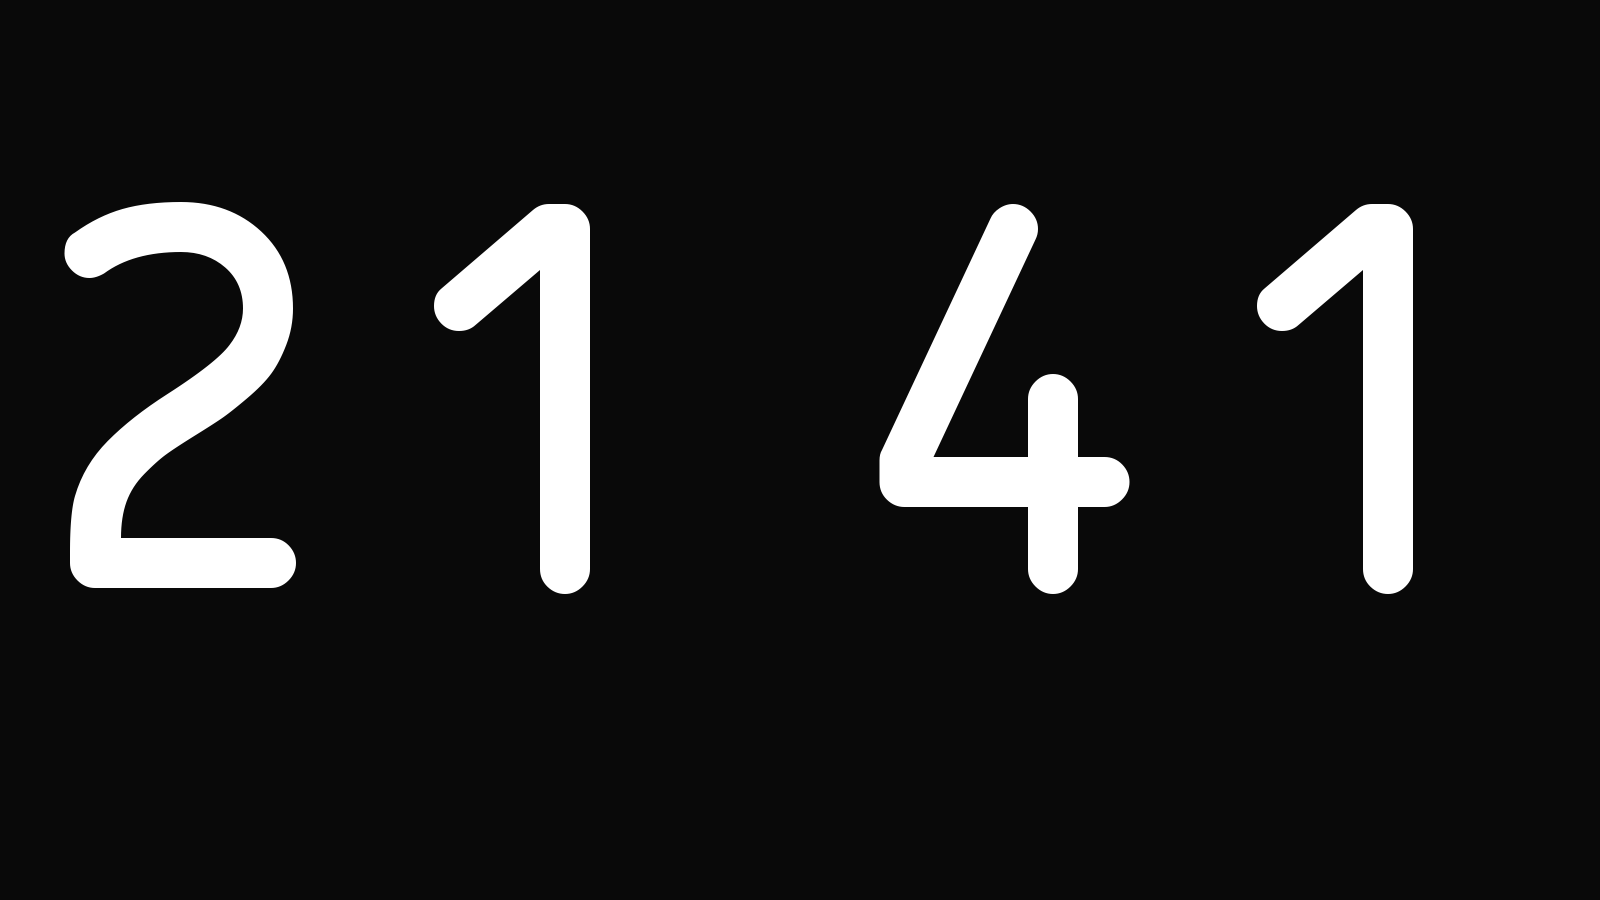

In [21]:
import numpy as np

Image.fromarray((np.array(mi) * 0.5 + np.array(cmi) * 0.5).astype(np.uint8))

In [22]:
mi.getbbox()

(0, 0, 1600, 900)

In [26]:
ImageOps.invert(mi).getbbox()

(0, 0, 1600, 900)

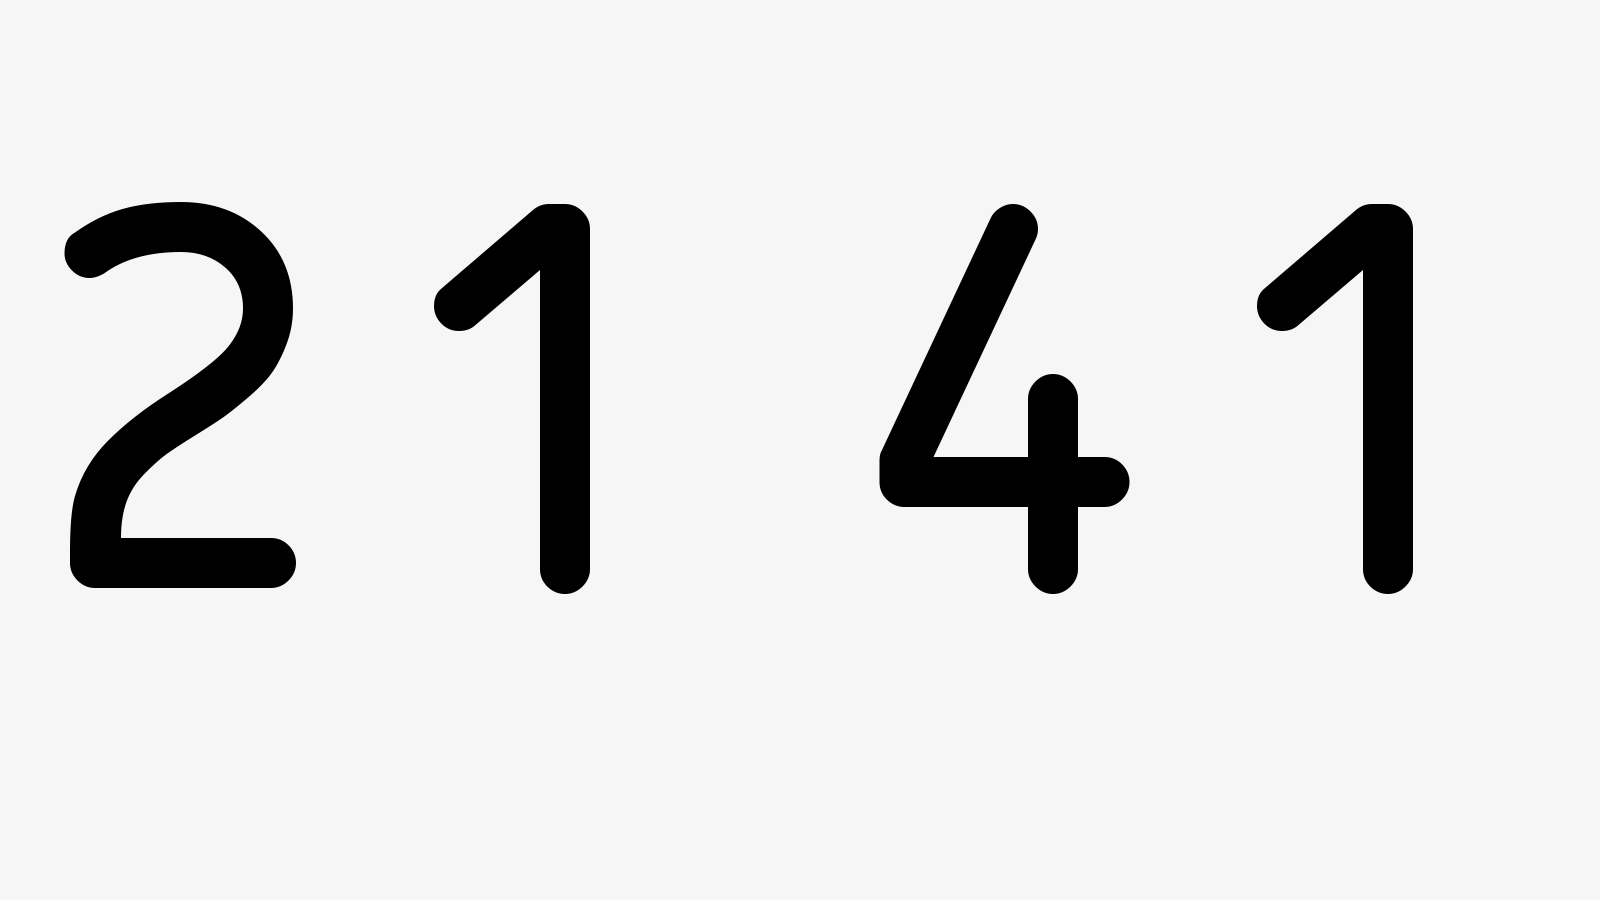

In [24]:
ImageOps.invert(cmi)

In [28]:
mi.getbbox??

Signature: mi.getbbox(*, alpha_only: 'bool' = True) -> 'tuple[int, int, int, int]'
Source:   
    def getbbox(self, *, alpha_only: bool = True) -> tuple[int, int, int, int]:
        """
        Calculates the bounding box of the non-zero regions in the
        image.

        :param alpha_only: Optional flag, defaulting to ``True``.
           If ``True`` and the image has an alpha channel, trim transparent pixels.
           Otherwise, trim pixels when all channels are zero.
           Keyword-only argument.
        :returns: The bounding box is returned as a 4-tuple defining the
           left, upper, right, and lower pixel coordinate. See
           :ref:`coordinate-system`. If the image is completely empty, this
           method returns None.

        """

        self.load()
        return self.im.getbbox(alpha_only)
File:      ~/jupyterlab/.direnv/python-3.11/lib/python3.11/site-packages/PIL/Image.py
Type:      method